In [1]:
pip install numpy pandas nltk tensorflow scikit-learn jupyter matplotlib seaborn


In [2]:
import re
from tqdm import tqdm_notebook

from nltk.corpus import stopwords
import pandas as pd
from tensorflow.keras import regularizers, initializers, optimizers, callbacks
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [3]:
MAX_NB_WORDS = 100000    # max no. of words for tokenizer
MAX_SEQUENCE_LENGTH = 200 # max length of each entry (sentence), including padding
VALIDATION_SPLIT = 0.2   # data for validation (not used in training)
EMBEDDING_DIM = 100      # embedding dimensions for word vectors (word2vec/GloVe)
GLOVE_DIR = "glove/glove.6B."+str(EMBEDDING_DIM)+"d.txt"

In [4]:
train = pd.read_csv('comment-toxicity-RNN\data/train.csv')
test = pd.read_csv('comment-toxicity-RNN\data/test.csv')

In [5]:
print(train.head())

                 id                                       comment_text  toxic  \
0  0000997932d777bf  Explanation\nWhy the edits made under my usern...      0   
1  000103f0d9cfb60f  D'aww! He matches this background colour I'm s...      0   
2  000113f07ec002fd  Hey man, I'm really not trying to edit war. It...      0   
3  0001b41b1c6bb37e  "\nMore\nI can't make any real suggestions on ...      0   
4  0001d958c54c6e35  You, sir, are my hero. Any chance you remember...      0   

   severe_toxic  obscene  threat  insult  identity_hate  
0             0        0       0       0              0  
1             0        0       0       0              0  
2             0        0       0       0              0  
3             0        0       0       0              0  
4             0        0       0       0              0  


In [6]:
train.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [7]:
test.isnull().sum()

id              0
comment_text    0
dtype: int64

In [8]:
labels = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
print(train.columns.tolist())
y = train[labels].values
comments_train = train['comment_text']
comments_test = test['comment_text']

['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [9]:
comments_train = list(comments_train)

In [10]:
def clean_text(text, remove_stopwords = True):
    output = ""
    text = str(text).replace("\n", "")
    text = re.sub(r'[^\w\s]','',text).lower()
    if remove_stopwords:
        text = text.split(" ")
        for word in text:
            if word not in stopwords.words("english"):
                output = output + " " + word
    else:
        output = text
    return str(output.strip())[1:-3].replace("  ", " ")

In [11]:
texts = [] 

for line in tqdm_notebook(comments_train, total=159571): 
    texts.append(clean_text(line))

C:\Users\bhavy\AppData\Local\Temp\ipykernel_12984\3406933657.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for line in tqdm_notebook(comments_train, total=159571):


  0%|          | 0/159571 [00:00<?, ?it/s]

In [12]:
print('Sample data:', texts[1], y[1])

Sample data: aww matches background colour im seemingly stuck thanks talk 2151 january 11 2016  [0 0 0 0 0 0]


In [13]:
tokenizer = Tokenizer(num_words=MAX_NB_WORDS)
tokenizer.fit_on_texts(texts)

In [14]:
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Vocabulary size:', len(word_index))

Vocabulary size: 324669


In [15]:
data = pad_sequences(sequences, padding = 'post', maxlen = MAX_SEQUENCE_LENGTH)

print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', y.shape)

Shape of data tensor: (159571, 200)
Shape of label tensor: (159571, 6)


In [16]:
import numpy as np

indices = np.arange(data.shape[0])
np.random.shuffle(indices)
data = data[indices]
labels = y[indices]

In [17]:
num_validation_samples = int(VALIDATION_SPLIT*data.shape[0])
x_train = data[: -num_validation_samples]
y_train = labels[: -num_validation_samples]
x_val = data[-num_validation_samples: ]
y_val = labels[-num_validation_samples: ]

In [18]:
print('Number of entries in each category:')
print('training: ', y_train.sum(axis=0))
print('validation: ', y_val.sum(axis=0))

Number of entries in each category:
training:  [12140  1250  6666   360  6237  1116]
validation:  [3154  345 1783  118 1640  289]


In [19]:
print('Tokenized sentences: \n', data[10])
print('One hot label: \n', labels[10])

Tokenized sentences: 
 [  606   303   282 34587   790   103     6    16   474    54  3411   282
   222    22   861   176  5122    58   235 15621    55    36   504  7074
    60   975   279  2482   123    31  5967   661   622 30603     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0    

In [20]:
GLOVE_DIR = "comment-toxicity-RNN\input\glove.6B.100d.txt"
# Or maybe referencing other variables like BASE_DIR, etc

In [21]:
embeddings_index = {}
f = open(GLOVE_DIR, encoding='utf-8')
print('Loading GloVe from:', GLOVE_DIR,'...', end='')
for line in f:
    values = line.split()
    word = values[0]
    embeddings_index[word] = np.asarray(values[1:], dtype='float32')
f.close()
print("Done.\n Proceeding with Embedding Matrix...", end="")

embedding_matrix = np.random.random((len(word_index) + 1, EMBEDDING_DIM))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
print(" Completed!")

Loading GloVe from: comment-toxicity-RNN\input\glove.6B.100d.txt ...Done.
 Proceeding with Embedding Matrix... Completed!


In [22]:
sequence_input = Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32')
embedding_layer = Embedding(len(word_index) + 1,
                           EMBEDDING_DIM,
                           weights = [embedding_matrix],
                           input_length = MAX_SEQUENCE_LENGTH,
                           trainable=False,
                           name = 'embeddings')
embedded_sequences = embedding_layer(sequence_input)

b:\RNN_FINAL_SHOW\.venv\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
x = LSTM(60, return_sequences=True,name='lstm_layer')(embedded_sequences)
x = GlobalMaxPool1D()(x)
x = Dropout(0.1)(x)
x = Dense(50, activation="relu")(x)
x = Dropout(0.1)(x)
preds = Dense(6, activation="sigmoid")(x)

In [24]:
model = Model(sequence_input, preds)
model.compile(loss = 'binary_crossentropy',
             optimizer='adam',
             metrics = ['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embeddings (Embedding)          │ (None, 200, 100)       │    32,467,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_layer (LSTM)               │ (None, 200, 60)        │        38,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 60)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         3,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,508,996 (124.01 MB)

 Trainable params: 41,996 (164.05 KB)

 Non-trainable params: 32,467,000 (123.85 MB)

In [25]:
print('Training progress:')
history = model.fit(x_train, y_train, epochs = 25, batch_size=32, validation_data=(x_val, y_val))

Training progress:
Epoch 1/25
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 147s 37ms/step - accuracy: 0.8232 - loss: 0.0997 - val_accuracy: 0.9934 - val_loss: 0.0691
Epoch 2/25
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 147s 37ms/step - accuracy: 0.9855 - loss: 0.0661 - val_accuracy: 0.9933 - val_loss: 0.0648
Epoch 3/25
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 146s 37ms/step - accuracy: 0.9894 - loss: 0.0601 - val_accuracy: 0.9934 - val_loss: 0.0637
Epoch 4/25
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 146s 37ms/step - accuracy: 0.9914 - loss: 0.0571 - val_accuracy: 0.9935 - val_loss: 0.0620
Epoch 5/25
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 147s 37ms/step - accuracy: 0.9929 - loss: 0.0534 - val_accuracy: 0.9933 - val_loss: 0.0618
Epoch 6/25
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 147s 37ms/step - accuracy: 0.9902 - loss: 0.0522 - val_accuracy: 0.9931 - val_loss: 0.0630
Epoch 7/25
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 147s 37ms/step - accuracy: 0.9926 - loss: 0.0493 - val_accuracy: 0.9934 - val_loss: 0.0612
Epoch 8/25
3990/3990 ━━━━━━━━━━━━━━━━━━━━ 146s 37m

In [27]:
import matplotlib.pyplot as plt

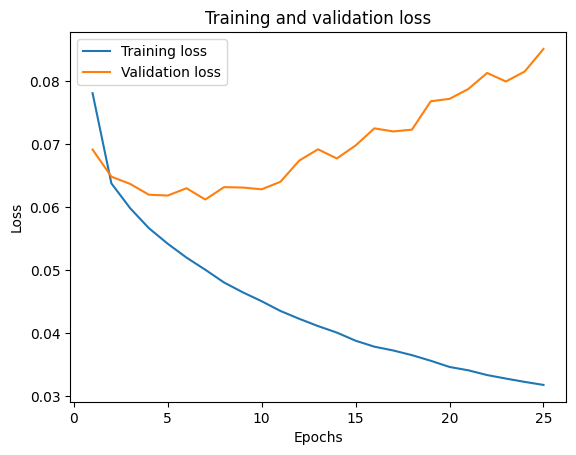

In [28]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();

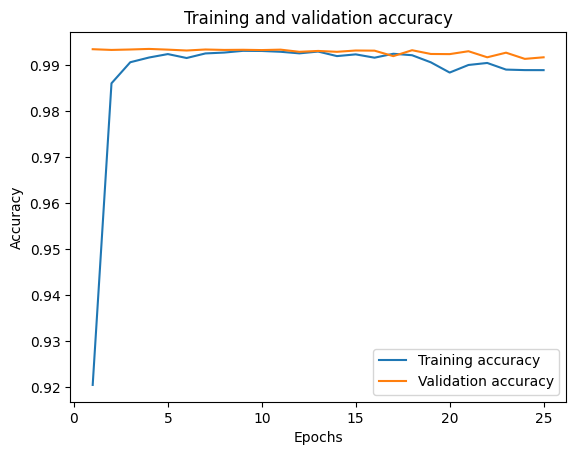

In [29]:
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.plot(epochs, accuracy, label='Training accuracy')
plt.plot(epochs, val_accuracy, label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend()
plt.show();

In [30]:

loss, accuracy = model.evaluate(x_val, y_val, verbose=0)


print(f'Validation Loss: {loss}')
print(f'Validation Accuracy: {accuracy}')



Validation Loss: 0.0851157158613205
Validation Accuracy: 0.9916651248931885


In [31]:

model.save('toxic_comment_model.h5')

print("Model saved successfully as toxic_comment_model.h5")



Model saved successfully as toxic_comment_model.h5


In [ ]:

from sklearn.metrics import roc_auc_score


y_pred_proba = model.predict(x_val)


auc_score = roc_auc_score(y_val, y_pred_proba)


print(f'Validation ROC AUC Score: {auc_score:.4f}') 




998/998 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step
Validation ROC AUC Score: 0.9607


In [ ]:


import numpy as np
from sklearn.metrics import classification_report


class_names = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


y_pred_proba = model.predict(x_val)


threshold = 0.5
y_pred_binary = (y_pred_proba > threshold).astype(int)


try:
    report = classification_report(
        y_val,
        y_pred_binary,
        target_names=class_names,
        zero_division=0
    )

   
    print("Classification Report:\n")
    print(report)

except ValueError as e:
    print(f"Error generating classification report: {e}")
    print("\nPlease ensure 'y_val' and 'y_pred_binary' have the correct shape and format.")
    print(f"Expected target_names length: {len(class_names)}")



998/998 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step
Classification Report:

               precision    recall  f1-score   support

        toxic       0.76      0.65      0.70      3154
 severe_toxic       0.54      0.18      0.27       345
      obscene       0.80      0.71      0.75      1783
       threat       0.58      0.18      0.27       118
       insult       0.70      0.60      0.64      1640
identity_hate       0.53      0.34      0.42       289

    micro avg       0.74      0.61      0.67      7329
    macro avg       0.65      0.44      0.51      7329
 weighted avg       0.73      0.61      0.66      7329
  samples avg       0.06      0.06      0.05      7329

